In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
df = pd.read_csv(
    "IMDB Dataset.csv",
    engine="python",
    encoding="latin-1",
    on_bad_lines="skip"
)

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [13]:
# Convert sentiment → 0/1
label_encoder = LabelEncoder()
df['sentiment'] = label_encoder.fit_transform(df['sentiment'])  
# positive → 1, negative → 0

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

# Tokenization (convert text → numbers)
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding (make equal length)
max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


In [19]:
model = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=32, input_length=max_len),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.build(input_shape=(None, max_len))
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │         409,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 731,777 (2.79 MB)

 Trainable params: 731,777 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7686 - loss: 0.4458 - val_accuracy: 0.8660 - val_loss: 0.3079
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9410 - loss: 0.1605 - val_accuracy: 0.8507 - val_loss: 0.3829
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9894 - loss: 0.0356 - val_accuracy: 0.8613 - val_loss: 0.4717
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9988 - loss: 0.0059 - val_accuracy: 0.8637 - val_loss: 0.5634
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9998 - loss: 5.6024e-04 - val_accuracy: 0.8627 - val_loss: 0.6366


In [29]:
# 1. Evaluate model
loss, accuracy = model.evaluate(X_test_pad, y_test)

# 2. Predictions
predictions = model.predict(X_test_pad)
y_pred = (predictions > 0.5).astype("int32")

# 3. Manual accuracy
manual_acc = np.mean(y_pred.flatten() == y_test)

# 4. Print results
print("\nTest Loss:", loss)
print("Test Accuracy (Keras):", accuracy)
print("Manual Accuracy:", manual_acc)
print("Accuracy (%):", accuracy * 100)

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8622 - loss: 0.6381
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Test Loss: 0.6380608677864075
Test Accuracy (Keras): 0.8622392416000366
Manual Accuracy: 0.862239242164668
Accuracy (%): 86.22392416000366


In [33]:
predictions = model.predict(X_test_pad)
y_pred = (predictions > 0.5).astype("int32")

print("\nSample Predictions:")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]}, Predicted: {int(y_pred[i])}")

311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

Sample Predictions:
Actual: 1, Predicted: 1
Actual: 1, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1


C:\Users\sai\AppData\Local\Temp\ipykernel_216\1506238774.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Actual: {y_test.iloc[i]}, Predicted: {int(y_pred[i])}")


In [35]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[4258  716]
 [ 651 4298]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4974
           1       0.86      0.87      0.86      4949

    accuracy                           0.86      9923
   macro avg       0.86      0.86      0.86      9923
weighted avg       0.86      0.86      0.86      9923



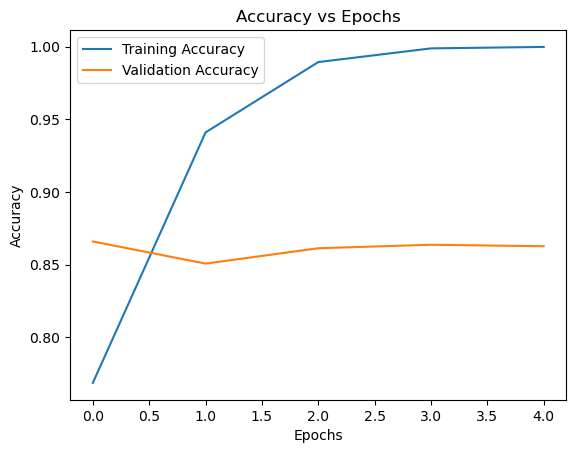

In [37]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [39]:
for i in range(5):
    print("Review Sentiment:", "Positive" if y_test.iloc[i] == 1 else "Negative")
    print("Predicted:", "Positive" if y_pred[i] == 1 else "Negative")
    print("Confidence:", float(predictions[i]))
    print("-"*50)

Review Sentiment: Positive
Predicted: Positive
Confidence: 0.9997535347938538
--------------------------------------------------
Review Sentiment: Positive
Predicted: Negative
Confidence: 0.34011638164520264
--------------------------------------------------
Review Sentiment: Negative
Predicted: Negative
Confidence: 0.00012407536269165576
--------------------------------------------------
Review Sentiment: Negative
Predicted: Negative
Confidence: 7.088468555593863e-05
--------------------------------------------------
Review Sentiment: Negative
Predicted: Negative
Confidence: 2.1474643290275708e-05
--------------------------------------------------


C:\Users\sai\AppData\Local\Temp\ipykernel_216\2544578227.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Confidence:", float(predictions[i]))


311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


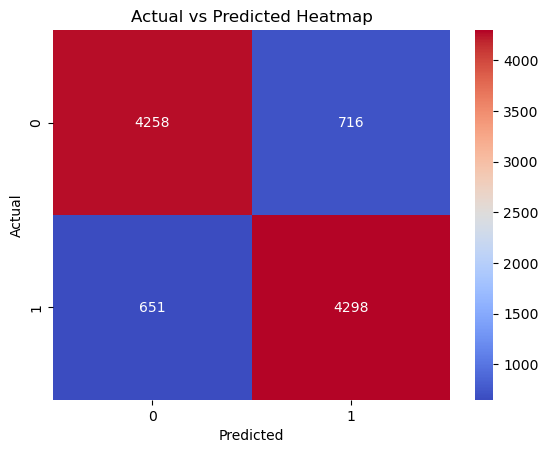

In [49]:
# Predictions
predictions = model.predict(X_test_pad)

# Convert to 0/1
y_pred = (predictions > 0.5).astype("int32")

# Flatten to 1D
y_pred_flat = y_pred.flatten()
import seaborn as sns

# Create confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_flat)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")

plt.title("Actual vs Predicted Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

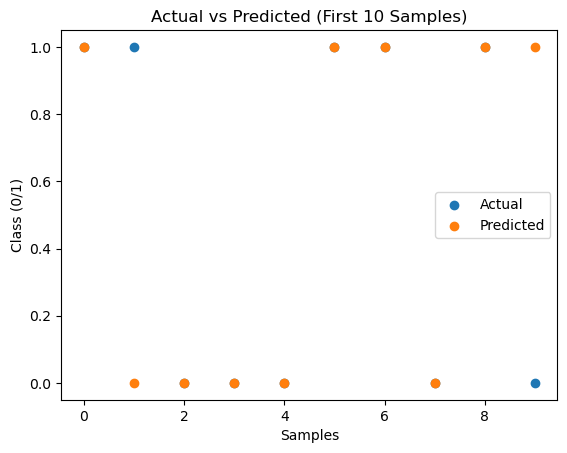

In [57]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(range(len(y_test[:10])), y_test[:10], label="Actual")
plt.scatter(range(len(y_pred_flat[:10])), y_pred_flat[:10], label="Predicted")
plt.title("Actual vs Predicted (First 10 Samples)")
plt.xlabel("Samples")
plt.ylabel("Class (0/1)")
plt.legend()
plt.show()